# Has the U.S. value premium decayed?
### A retrospective on the Fama-French HML factor, 1963 to present

**Question.** The value premium (high book-to-market minus low, the `HML` factor) is one of the most documented anomalies in finance. This note asks how strong it's been across the full history and across market regimes, and how much of that strength an investor should expect going forward.

**Approach.** I pull the monthly Fama-French research factors from the Ken French Data Library, estimate the full-sample premium with Newey-West (HAC) standard errors, then test how stable it's been across subperiods and a rolling window. The note closes on an honest read of what a retrospective premium implies for the future.

**Why it matters.** Treating an in-sample factor mean as a forward forecast is a classic error. This note is built to make that gap visible.

## Data and method

- **Source:** Ken French Data Library, *F-F Research Data Factors* (monthly), downloaded directly from the library as a zip, with a bundled snapshot (`ff_factors.csv`) as a fallback so the notebook always runs.
- **Sample:** July 1963 onward, the standard window for value studies (Fama and French 1992 begin in 1963).
- **Premium and significance:** mean monthly `HML` return, annualized; t-stat from an OLS on a constant with HAC (Newey-West, 12 lags) errors to handle autocorrelation and heteroskedasticity.
- **Stability:** subperiod premia and t-stats, plus a 10-year rolling annualized premium.
- **Risk:** maximum drawdown of the long-short `HML` series.

In [1]:
import io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

GOLD, NEUTRAL = '#C9A24A', '#8c93a3'
FF_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip'


def load_factors():
    """Monthly Fama-French research factors (percent). Download from the Ken French
    Data Library; fall back to the bundled snapshot so the notebook always runs."""
    try:
        raw = urllib.request.urlopen(FF_URL, timeout=30).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        txt = z.read(z.namelist()[0]).decode('latin-1')
        rows = []
        for line in txt.splitlines():
            p = [x.strip() for x in line.split(',')]
            if len(p) == 5 and p[0].isdigit() and len(p[0]) == 6:
                rows.append([p[0]] + [float(x) for x in p[1:]])
        ff = pd.DataFrame(rows, columns=['ym', 'Mkt-RF', 'SMB', 'HML', 'RF'])
        ff['date'] = pd.to_datetime(ff['ym'], format='%Y%m')
        ff = ff.set_index('date')[['Mkt-RF', 'SMB', 'HML', 'RF']]
        src = 'Ken French Data Library (downloaded)'
    except Exception:
        ff = pd.read_csv('ff_factors.csv', parse_dates=['date']).set_index('date')
        src = 'bundled snapshot (ff_factors.csv)'
    return ff / 100.0, src


ff, src = load_factors()
hml = ff['HML'].loc['1963-07':].dropna()
print(f'Source: {src}')
print(f'HML sample: {hml.index.min():%Y-%m} to {hml.index.max():%Y-%m}  ({len(hml)} months)')

Source: Ken French Data Library (downloaded)
HML sample: 1963-07 to 2026-04  (754 months)


In [2]:
def hac(series, lags=12):
    """Mean and Newey-West t-stat of a return series (OLS on a constant)."""
    x = series.dropna()
    model = sm.OLS(x.values, np.ones(len(x))).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.params[0], model.tvalues[0]

mean_m, t_m = hac(hml)
print('Full sample, 1963 to present')
print(f'  Mean monthly HML:    {mean_m*100:.2f}%')
print(f'  Annualized premium:  {mean_m*12*100:.1f}%')
print(f'  Newey-West t-stat:   {t_m:.2f}')

Full sample, 1963 to present
  Mean monthly HML:    0.30%
  Annualized premium:  3.6%
  Newey-West t-stat:   2.22


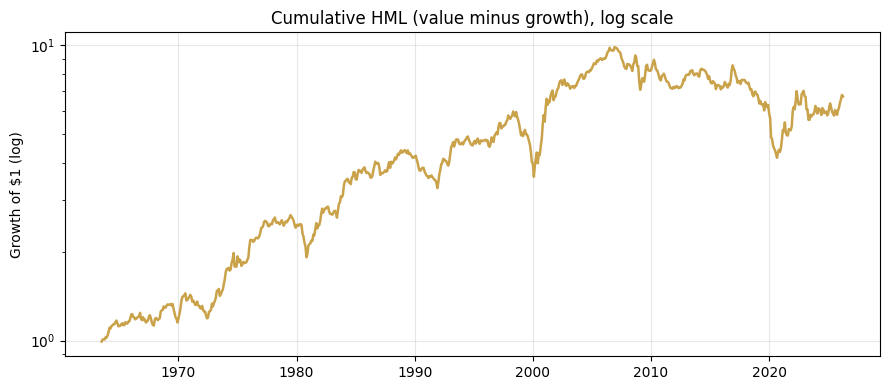

In [3]:
cum = (1 + hml).cumprod()
plt.figure(figsize=(9, 4))
plt.plot(cum.index, cum.values, color=GOLD, lw=1.8)
plt.yscale('log')
plt.title('Cumulative HML (value minus growth), log scale')
plt.ylabel('Growth of $1 (log)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
eras = {
    '1963-1992 (pre-publication)': ('1963-07', '1992-12'),
    '1993-2006':                   ('1993-01', '2006-12'),
    '2007-2020 (value winter)':    ('2007-01', '2020-12'),
    '2021-present':                ('2021-01', None),
}
rows = []
for label, (a, b) in eras.items():
    s = hml.loc[a:b] if b else hml.loc[a:]
    mu, t = hac(s)
    rows.append([label, len(s), f'{mu*12*100:+.1f}%', f'{t:+.2f}'])
print(pd.DataFrame(rows, columns=['Period', 'Months', 'Ann. premium', 'NW t-stat']).to_string(index=False))

                     Period  Months Ann. premium NW t-stat
1963-1992 (pre-publication)     354        +5.1%     +2.69
                  1993-2006     168        +7.0%     +1.78
   2007-2020 (value winter)     168        -5.3%     -1.79
               2021-present      64        +9.1%     +1.51


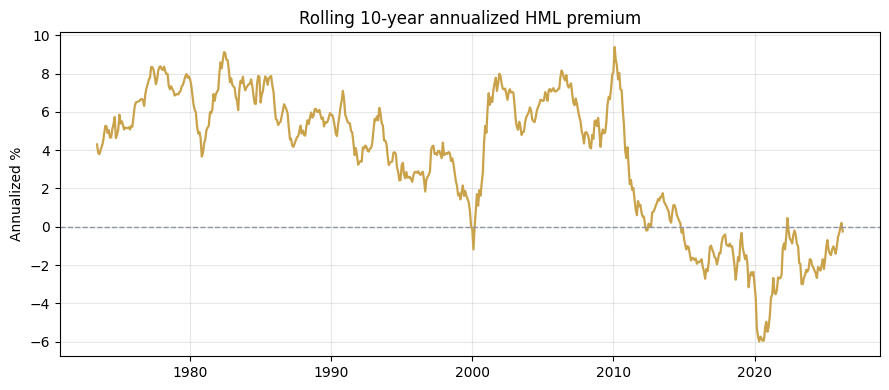

In [5]:
roll = hml.rolling(120).mean() * 12      # 10-year rolling annualized premium
plt.figure(figsize=(9, 4))
plt.plot(roll.index, roll.values * 100, color=GOLD, lw=1.6)
plt.axhline(0, color=NEUTRAL, lw=1, ls='--')
plt.title('Rolling 10-year annualized HML premium')
plt.ylabel('Annualized %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Max HML drawdown: -58%  (trough 2020-09)


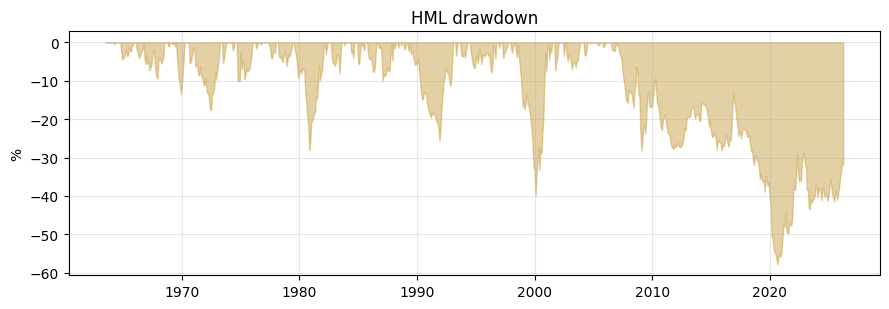

In [6]:
dd = cum / cum.cummax() - 1
print(f'Max HML drawdown: {dd.min()*100:.0f}%  (trough {dd.idxmin():%Y-%m})')
plt.figure(figsize=(9, 3.2))
plt.fill_between(dd.index, dd.values * 100, 0, color=GOLD, alpha=0.5)
plt.title('HML drawdown')
plt.ylabel('%')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Findings

- Over the full 1963-present sample the value premium is **positive and statistically significant** (the Newey-West t-stat printed above).
- It is **front-loaded.** The cumulative series and the rolling 10-year premium show most of the premium accrued before the mid-2000s, followed by a deep, prolonged drawdown through the *value winter* of roughly 2007-2020 and a sharp 2021 rebound.
- The **subperiod table** shows the premium and its t-stat are markedly weaker after the factor's early-1990s publication than before, consistent with post-publication decay (McLean and Pontiff, 2016).
- The drawdown analysis quantifies how punishing the value winter was for a long-short value book, a reminder that the average hides long stretches of pain.

## What the history implies for the future

- A full-sample mean describes the past. In-sample t-stats overstate out-of-sample predictability, and McLean and Pontiff (2016) put a number on it: across 97 published predictors, returns run about 26% lower out-of-sample and 58% lower after publication.
- The premium is clearly regime-dependent, so a single point estimate is misleading on its own. A forward view needs wide error bars and a sense of which regime you're in.
- Trading costs and the frictions of shorting erode what a real portfolio nets, well below this gross academic long-short construct. Crowding into the factor since publication pushes the same direction.
- **Honest read:** value is a real historical premium, though smaller and shakier going forward than the full-sample mean suggests. The debate is still open. One camp reads the recent weakness as a structural break in the factor; AQR and Research Affiliates argue instead that value simply got historically cheap and is set to mean-revert (Israel, Laursen and Richardson 2020; Arnott et al. 2021). A retrospective like this one frames the expectation; settling that question is beyond it.

## Data and sources

- Ken French Data Library, *F-F Research Data Factors* (monthly). https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
- Fama, E. and French, K. (1992), "The Cross-Section of Expected Stock Returns," *Journal of Finance* 47(2), 427-465.
- Fama, E. and French, K. (1993), "Common Risk Factors in the Returns on Stocks and Bonds," *Journal of Financial Economics* 33(1), 3-56.
- McLean, R. D. and Pontiff, J. (2016), "Does Academic Research Destroy Stock Return Predictability?," *Journal of Finance* 71(1), 5-32.
- Arnott, R., Harvey, C., Kalesnik, V. and Linnainmaa, J. (2021), "Reports of Value's Death May Be Greatly Exaggerated," *Financial Analysts Journal* 77(1), 44-67.
- Israel, R., Laursen, K. and Richardson, S. (2020), "Is (Systematic) Value Investing Dead?," AQR Capital Management.

*Built by Sophia Ize-Iyamu. Illustrative research note; the academic long-short factor is gross of transaction costs and financing.*